# Implementation of the VanillaRNN class

In [62]:
import numpy as np


# ==========================================
# Part A and B: Implementation of the RNN class
# ==========================================
class BatchedVanillaRNN:
    def __init__(self, features, hidden_size, output_size):
        self.features = features
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Initialize weights with a normal (Gaussian) distribution to prevent early tanh saturation
        self.W_combined = np.random.randn(features + hidden_size, hidden_size) * 0.1
        self.b_h = np.zeros((1, hidden_size))
        
        self.W_y = np.random.randn(hidden_size, output_size) * 0.1
        self.b_y = np.zeros((1, output_size))
        
    def forward(self, inputs):
        batch_size, seq_len, features = inputs.shape
        
        self.cache = []
        h_prev = np.zeros((batch_size, self.hidden_size))
        outputs = np.zeros((batch_size, seq_len, self.output_size))
        
        for t in range(seq_len):
            x_t = inputs[:, t, :]
            # Matrix concatenation trick
            concat_input = np.concatenate((x_t, h_prev), axis=1)
            
            # Single matrix multiplication
            h_raw = np.dot(concat_input, self.W_combined) + self.b_h
            h_next = np.tanh(h_raw)
            y_t = np.dot(h_next, self.W_y) + self.b_y
            
            self.cache.append((concat_input, h_next))
            outputs[:, t, :] = y_t
            h_prev = h_next
            
        return outputs

    def backward(self, d_outputs):
        dW_combined = np.zeros_like(self.W_combined)
        db_h = np.zeros_like(self.b_h)
        dW_y = np.zeros_like(self.W_y)
        db_y = np.zeros_like(self.b_y)
        
        batch_size, seq_len, _ = d_outputs.shape
        dh_next = np.zeros((batch_size, self.hidden_size))
        
        for t in reversed(range(seq_len)):
            dy_t = d_outputs[:, t, :]
            concat_input, h_t = self.cache[t]
            
            if np.any(dy_t != 0):
                dW_y += np.dot(h_t.T, dy_t)
                db_y += np.sum(dy_t, axis=0, keepdims=True)
            
            dh_t = np.dot(dy_t, self.W_y.T) + dh_next
            dtanh = (1 - h_t ** 2) * dh_t
            
            dW_combined += np.dot(concat_input.T, dtanh)
            db_h += np.sum(dtanh, axis=0, keepdims=True)
            
            d_concat_input = np.dot(dtanh, self.W_combined.T)
            dh_next = d_concat_input[:, self.features:]
            
        gradients = {
            'dW_combined': dW_combined, 'db_h': db_h,
            'dW_y': dW_y, 'db_y': db_y
        }
        return gradients


# Implementing Softmax and Cross_entropy_loss

In [63]:
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

def cross_entropy_loss(probs, y_true):
    n_samples = y_true.shape[0]
    log_likelihood = -np.log(probs[range(n_samples), y_true] + 1e-9)
    loss = np.sum(log_likelihood) / n_samples
    
    grad = probs.copy()
    grad[range(n_samples), y_true] -= 1
    grad /= n_samples
    return loss, grad

# Generating Data

In [64]:
def generate_data(num_samples, seq_len):
    X = np.random.randint(0, 2, size=(num_samples, seq_len))
    y = np.sum(X, axis=1) % 2
    
    X_onehot = np.zeros((num_samples, seq_len, 2))
    for i in range(num_samples):
        for t in range(seq_len):
            X_onehot[i, t, X[i, t]] = 1
            
    return X_onehot, y

# Training model on the train set(S_L=3,Lr=0.9,Epochs=500), Inference on the test set and evaluate it 

In [71]:
if __name__ == "__main__":
    np.random.seed(42)
    # 1. Explicit definition of network dimensions
    BATCH_SIZE = 800         # Training batch size
    SEQUENCE_LENGTH = 3      # Length of time sequence
    FEATURES = 2             # Number of features at each timestep (binary one-hot)
    
    HIDDEN_SIZE = 32
    OUTPUT_SIZE = 2
    LEARNING_RATE = 0.9
    EPOCHS = 500
    TOTAL_SAMPLES = 1000
    CLIP_THRESHOLD = 1

    # 2. Generate and split data into Train (80%) and Test (20%)
    X_all, y_all = generate_data(TOTAL_SAMPLES, SEQUENCE_LENGTH)
    
    X_train, y_train = X_all[:BATCH_SIZE], y_all[:BATCH_SIZE]
    X_test, y_test = X_all[BATCH_SIZE:], y_all[BATCH_SIZE:]
    
    print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

    rnn = BatchedVanillaRNN(FEATURES, HIDDEN_SIZE, OUTPUT_SIZE)
    
    loss_history = []
    acc_history = []
    
    print("\n--- Training Start ---")
    for epoch in range(EPOCHS):
        outputs = rnn.forward(X_train)
        last_outputs = outputs[:, -1, :]  # Many-to-One
        
        probs = softmax(last_outputs)
        loss, d_loss = cross_entropy_loss(probs, y_train)
        
        # Calculate accuracy on training data
        predictions = np.argmax(probs, axis=1)
        accuracy = np.mean(predictions == y_train)
        
        loss_history.append(loss)
        acc_history.append(accuracy)
        
        d_outputs = np.zeros_like(outputs)
        d_outputs[:, -1, :] = d_loss
        
        gradients = rnn.backward(d_outputs)
        
        # Gradient clipping
        for key in gradients:
            np.clip(gradients[key], -CLIP_THRESHOLD, CLIP_THRESHOLD, out=gradients[key])

        # Update weights
        rnn.W_combined -= LEARNING_RATE * gradients['dW_combined']
        rnn.b_h -= LEARNING_RATE * gradients['db_h']
        rnn.W_y -= LEARNING_RATE * gradients['dW_y']
        rnn.b_y -= LEARNING_RATE * gradients['db_y']
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {loss:.4f} | Acc: {accuracy*100:.1f}%")

    # 3. Evaluation on test data (unseen data)
    print("\n--- Evaluation on Test Data ---")
    test_outputs = rnn.forward(X_test)
    test_probs = softmax(test_outputs[:, -1, :])
    test_preds = np.argmax(test_probs, axis=1)
    
    test_accuracy = np.mean(test_preds == y_test)
    print(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    
    # Display some examples of model performance on test data
    print("Displaying first 5 test samples:")
    for i in range(5):
        seq = [np.argmax(x) for x in X_test[i]]  # Convert one-hot back to original numbers for display
        print(f"Sequence: {seq}")
        print(f"Model Prediction: {'Odd (1)' if test_preds[i] == 1 else 'Even (0)'} | True Label: {'Odd (1)' if y_test[i] == 1 else 'Even (0)'}")
        print("-" * 30)


Train Shape: (800, 3, 2) | Test Shape: (200, 3, 2)

--- Training Start ---
Epoch  50/500 | Loss: 0.6909 | Acc: 53.1%
Epoch 100/500 | Loss: 0.6908 | Acc: 53.1%
Epoch 150/500 | Loss: 0.6906 | Acc: 53.1%
Epoch 200/500 | Loss: 0.6897 | Acc: 39.9%
Epoch 250/500 | Loss: 0.1518 | Acc: 100.0%
Epoch 300/500 | Loss: 0.0122 | Acc: 100.0%
Epoch 350/500 | Loss: 0.0054 | Acc: 100.0%
Epoch 400/500 | Loss: 0.0033 | Acc: 100.0%
Epoch 450/500 | Loss: 0.0023 | Acc: 100.0%
Epoch 500/500 | Loss: 0.0018 | Acc: 100.0%

--- Evaluation on Test Data ---
Test Accuracy: 100.00%

Displaying first 5 test samples:
Sequence: [0, 1, 0]
Model Prediction: Odd (1) | True Label: Odd (1)
------------------------------
Sequence: [0, 0, 0]
Model Prediction: Even (0) | True Label: Even (0)
------------------------------
Sequence: [1, 0, 0]
Model Prediction: Odd (1) | True Label: Odd (1)
------------------------------
Sequence: [1, 0, 0]
Model Prediction: Odd (1) | True Label: Odd (1)
------------------------------
Sequence: [

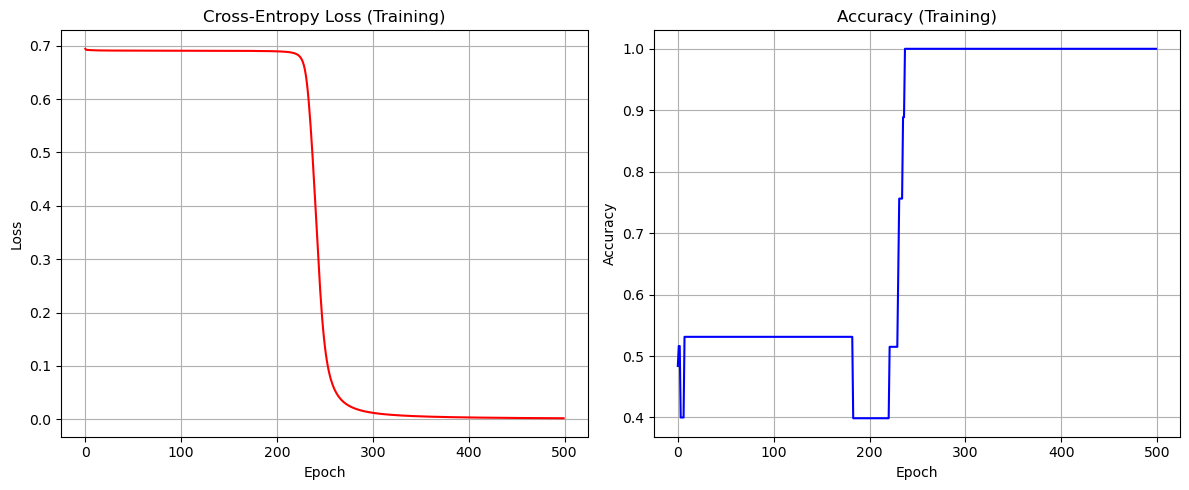

In [72]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
ax1.plot(loss_history, color='red')
ax1.set_title("Cross-Entropy Loss (Training)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)
    
ax2.plot(acc_history, color='blue')
ax2.set_title("Accuracy (Training)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)
    
plt.tight_layout()
plt.show()

# Training model on the train set(S_L=10,Lr=0.9,Epochs=2000), Inference on the test set and evaluate it 

In [73]:
if __name__ == "__main__":
    np.random.seed(42)
    BATCH_SIZE = 800         
    SEQUENCE_LENGTH = 10    
    FEATURES = 2             
    
    HIDDEN_SIZE = 32
    OUTPUT_SIZE = 2
    # Increase learning rate to 1.0 (because using vanilla SGD and gradients are averaged)
    LEARNING_RATE = 0.9
    EPOCHS = 2000
    TOTAL_SAMPLES = 1000
    CLIP_THRESHOLD = 1

    X_all, y_all = generate_data(TOTAL_SAMPLES, SEQUENCE_LENGTH)
    
    X_train, y_train = X_all[:BATCH_SIZE], y_all[:BATCH_SIZE]
    X_test, y_test = X_all[BATCH_SIZE:], y_all[BATCH_SIZE:]
    
    print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

    rnn = BatchedVanillaRNN(FEATURES, HIDDEN_SIZE, OUTPUT_SIZE)
    
    loss_history = []
    acc_history = []
    
    print("\n--- Training Start ---")
    for epoch in range(EPOCHS):
        outputs = rnn.forward(X_train)
        last_outputs = outputs[:, -1, :] 
        
        probs = softmax(last_outputs)
        loss, d_loss = cross_entropy_loss(probs, y_train)
        
        predictions = np.argmax(probs, axis=1)
        accuracy = np.mean(predictions == y_train)
        
        loss_history.append(loss)
        acc_history.append(accuracy)
        
        d_outputs = np.zeros_like(outputs)
        d_outputs[:, -1, :] = d_loss
        
        gradients = rnn.backward(d_outputs)
        
        for key in gradients:
            np.clip(gradients[key], -CLIP_THRESHOLD, CLIP_THRESHOLD, out=gradients[key])

        rnn.W_combined -= LEARNING_RATE * gradients['dW_combined']
        rnn.b_h -= LEARNING_RATE * gradients['db_h']
        rnn.W_y -= LEARNING_RATE * gradients['dW_y']
        rnn.b_y -= LEARNING_RATE * gradients['db_y']
        
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1:4d}/{EPOCHS} | Loss: {loss:.4f} | Acc: {accuracy*100:.1f}%")

    print("\n--- Evaluation on Test Data ---")
    test_outputs = rnn.forward(X_test)
    test_probs = softmax(test_outputs[:, -1, :])
    test_preds = np.argmax(test_probs, axis=1)
    
    test_accuracy = np.mean(test_preds == y_test)
    print(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    
    print("Displaying first 5 test samples:")
    for i in range(5):
        seq = [np.argmax(x) for x in X_test[i]] 
        print(f"Sequence: {seq}")
        print(f"Model Prediction: {'Odd (1)' if test_preds[i] == 1 else 'Even (0)'} | True Label: {'Odd (1)' if y_test[i] == 1 else 'Even (0)'}")
        print("-" * 30)


Train Shape: (800, 10, 2) | Test Shape: (200, 10, 2)

--- Training Start ---
Epoch  100/2000 | Loss: 0.6878 | Acc: 52.1%
Epoch  200/2000 | Loss: 0.6870 | Acc: 52.2%
Epoch  300/2000 | Loss: 0.6862 | Acc: 52.5%
Epoch  400/2000 | Loss: 0.6811 | Acc: 54.9%
Epoch  500/2000 | Loss: 0.6558 | Acc: 59.9%
Epoch  600/2000 | Loss: 0.5976 | Acc: 65.8%
Epoch  700/2000 | Loss: 0.5665 | Acc: 69.6%
Epoch  800/2000 | Loss: 0.3306 | Acc: 85.9%
Epoch  900/2000 | Loss: 0.6134 | Acc: 74.8%
Epoch 1000/2000 | Loss: 0.0618 | Acc: 99.5%
Epoch 1100/2000 | Loss: 0.0219 | Acc: 100.0%
Epoch 1200/2000 | Loss: 0.0122 | Acc: 100.0%
Epoch 1300/2000 | Loss: 0.0081 | Acc: 100.0%
Epoch 1400/2000 | Loss: 0.0060 | Acc: 100.0%
Epoch 1500/2000 | Loss: 0.0047 | Acc: 100.0%
Epoch 1600/2000 | Loss: 0.0038 | Acc: 100.0%
Epoch 1700/2000 | Loss: 0.0031 | Acc: 100.0%
Epoch 1800/2000 | Loss: 0.0027 | Acc: 100.0%
Epoch 1900/2000 | Loss: 0.0023 | Acc: 100.0%
Epoch 2000/2000 | Loss: 0.0021 | Acc: 100.0%

--- Evaluation on Test Data ---


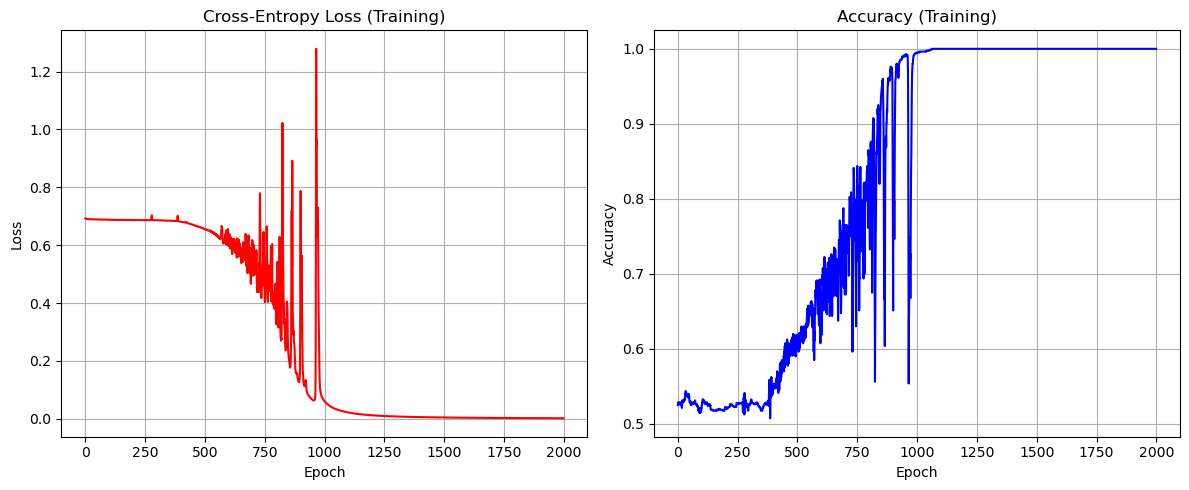

In [74]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
ax1.plot(loss_history, color='red')
ax1.set_title("Cross-Entropy Loss (Training)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)
    
ax2.plot(acc_history, color='blue')
ax2.set_title("Accuracy (Training)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)
    
plt.tight_layout()
plt.show()

# Training model on the train set(S_L=10,Lr=0.1,Epochs=2000), Inference on the test set and evaluate it 

In [76]:
if __name__ == "__main__":
    np.random.seed(42)
    BATCH_SIZE = 800         
    SEQUENCE_LENGTH = 10    
    FEATURES = 2             
    
    HIDDEN_SIZE = 32
    OUTPUT_SIZE = 2
    # Decrease learning rate to 0.1 (because we're using simple SGD and gradients are averaged)
    LEARNING_RATE = 0.1
    EPOCHS = 2000
    TOTAL_SAMPLES = 1000
    CLIP_THRESHOLD = 1

    X_all, y_all = generate_data(TOTAL_SAMPLES, SEQUENCE_LENGTH)
    
    X_train, y_train = X_all[:BATCH_SIZE], y_all[:BATCH_SIZE]
    X_test, y_test = X_all[BATCH_SIZE:], y_all[BATCH_SIZE:]
    
    print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

    rnn = BatchedVanillaRNN(FEATURES, HIDDEN_SIZE, OUTPUT_SIZE)
    
    loss_history = []
    acc_history = []
    
    print("\n--- Training Start ---")
    for epoch in range(EPOCHS):
        outputs = rnn.forward(X_train)
        last_outputs = outputs[:, -1, :] 
        
        probs = softmax(last_outputs)
        loss, d_loss = cross_entropy_loss(probs, y_train)
        
        predictions = np.argmax(probs, axis=1)
        accuracy = np.mean(predictions == y_train)
        
        loss_history.append(loss)
        acc_history.append(accuracy)
        
        d_outputs = np.zeros_like(outputs)
        d_outputs[:, -1, :] = d_loss
        
        gradients = rnn.backward(d_outputs)
        
        for key in gradients:
            np.clip(gradients[key], -CLIP_THRESHOLD, CLIP_THRESHOLD, out=gradients[key])

        rnn.W_combined -= LEARNING_RATE * gradients['dW_combined']
        rnn.b_h -= LEARNING_RATE * gradients['db_h']
        rnn.W_y -= LEARNING_RATE * gradients['dW_y']
        rnn.b_y -= LEARNING_RATE * gradients['db_y']
        
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1:4d}/{EPOCHS} | Loss: {loss:.4f} | Acc: {accuracy*100:.1f}%")

    print("\n--- Evaluation on Test Data ---")
    test_outputs = rnn.forward(X_test)
    test_probs = softmax(test_outputs[:, -1, :])
    test_preds = np.argmax(test_probs, axis=1)
    
    test_accuracy = np.mean(test_preds == y_test)
    print(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    
    print("Displaying first 5 test samples:")
    for i in range(5):
        seq = [np.argmax(x) for x in X_test[i]]
        print(f"Sequence: {seq}")
        print(f"Model Prediction: {'Odd (1)' if test_preds[i] == 1 else 'Even (0)'} | True Label: {'Odd (1)' if y_test[i] == 1 else 'Even (0)'}")
        print("-" * 30)


Train Shape: (800, 10, 2) | Test Shape: (200, 10, 2)

--- Training Start ---
Epoch  100/2000 | Loss: 0.6903 | Acc: 52.9%
Epoch  200/2000 | Loss: 0.6898 | Acc: 52.9%
Epoch  300/2000 | Loss: 0.6895 | Acc: 54.4%
Epoch  400/2000 | Loss: 0.6892 | Acc: 54.1%
Epoch  500/2000 | Loss: 0.6889 | Acc: 52.5%
Epoch  600/2000 | Loss: 0.6886 | Acc: 52.8%
Epoch  700/2000 | Loss: 0.6882 | Acc: 52.5%
Epoch  800/2000 | Loss: 0.6880 | Acc: 51.9%
Epoch  900/2000 | Loss: 0.6878 | Acc: 52.8%
Epoch 1000/2000 | Loss: 0.6876 | Acc: 52.9%
Epoch 1100/2000 | Loss: 0.6875 | Acc: 52.9%
Epoch 1200/2000 | Loss: 0.6874 | Acc: 52.6%
Epoch 1300/2000 | Loss: 0.6873 | Acc: 52.0%
Epoch 1400/2000 | Loss: 0.6872 | Acc: 51.7%
Epoch 1500/2000 | Loss: 0.6872 | Acc: 51.9%
Epoch 1600/2000 | Loss: 0.6871 | Acc: 51.9%
Epoch 1700/2000 | Loss: 0.6871 | Acc: 51.7%
Epoch 1800/2000 | Loss: 0.6870 | Acc: 52.2%
Epoch 1900/2000 | Loss: 0.6869 | Acc: 52.2%
Epoch 2000/2000 | Loss: 0.6868 | Acc: 52.6%

--- Evaluation on Test Data ---
Test Accur

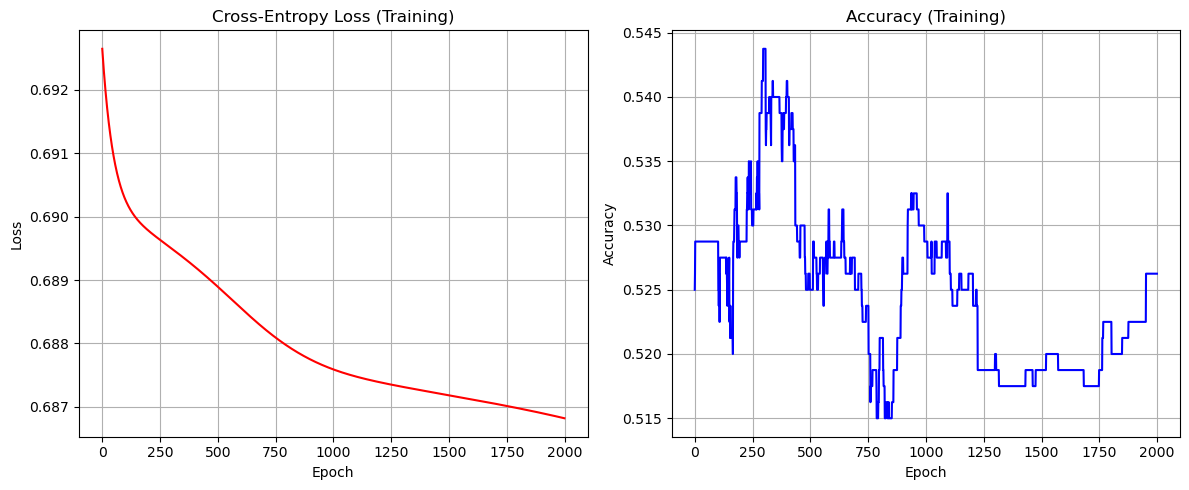

In [77]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
ax1.plot(loss_history, color='red')
ax1.set_title("Cross-Entropy Loss (Training)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)
    
ax2.plot(acc_history, color='blue')
ax2.set_title("Accuracy (Training)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)
    
plt.tight_layout()
plt.show()